# <b>Weather Image Recognition</b>

# 1. Import Libraries & Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [2]:
# Define path to weather images
weather_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/Prepared Data/Multi-class Weather Dataset"

In [3]:
# Create the imageDataGenerator
datagen = ImageDataGenerator(rescale=1./255)

In [5]:
# Check image imports
weather_generator = datagen.flow_from_directory(
    directory=weather_path,
    target_size=(150, 150),    
    batch_size=32,
    class_mode="categorical"
)

Found 1125 images belonging to 4 classes.


In [6]:
# Check image class labels
weather_generator.class_indices

{'Cloudy': 0, 'Rain': 1, 'Shine': 2, 'Sunrise': 3}

In [8]:
# Split: 80% train, 20% validation 
datagenerator = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagenerator.flow_from_directory(
    directory=weather_path,
    target_size=(150, 150),          
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

val_generator = datagenerator.flow_from_directory(
    directory=weather_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


# 2. CNN for Categorizing Images

In [9]:
inputs = Input(shape=(150, 150, 3))

x = Conv2D(32, (5, 5), activation='relu')(inputs)
x = MaxPooling2D(pool_size=(3, 3))(x)

x = Conv2D(64, (5, 5), activation='relu')(x)
x = MaxPooling2D(pool_size=(3, 3))(x)

x = Conv2D(128, (5, 5), activation='relu')(x)
x = MaxPooling2D(pool_size=(3, 3))(x)

x = Flatten()(x)
x = Dropout(0.5, seed=5)(x)
x = Dense(128, activation='relu')(x)

outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 146, 146, 32)      2432      
                                                                 
 max_pooling2d (MaxPooling2  (None, 48, 48, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 44, 44, 64)        51264     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 10, 10, 128)       204928

# 3. Test Epochs

In [11]:
# Compile and run model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_generator,
    epochs=10,
    steps_per_epoch=(train_generator.n // train_generator.batch_size) - 1,
    validation_data=val_generator, 
    validation_steps=(val_generator.n // val_generator.batch_size) - 1
)

Epoch 1/10
27/27 [==============================] - 6s 212ms/step - loss: 0.9364 - accuracy: 0.5472 - val_loss: 0.7718 - val_accuracy: 0.7552
Epoch 2/10
27/27 [==============================] - 6s 207ms/step - loss: 0.6187 - accuracy: 0.7611 - val_loss: 0.6541 - val_accuracy: 0.7812
Epoch 3/10
27/27 [==============================] - 6s 206ms/step - loss: 0.5581 - accuracy: 0.7885 - val_loss: 0.5580 - val_accuracy: 0.7812
Epoch 4/10
27/27 [==============================] - 5s 197ms/step - loss: 0.5449 - accuracy: 0.7969 - val_loss: 0.9745 - val_accuracy: 0.6250
Epoch 5/10
27/27 [==============================] - 6s 203ms/step - loss: 0.5152 - accuracy: 0.8029 - val_loss: 0.9386 - val_accuracy: 0.7188
Epoch 6/10
27/27 [==============================] - 6s 205ms/step - loss: 0.4837 - accuracy: 0.8076 - val_loss: 0.6034 - val_accuracy: 0.7656
Epoch 7/10
27/27 [==============================] - 6s 216ms/step - loss: 0.3966 - accuracy: 0.8399 - val_loss: 0.5092 - val_accuracy: 0.7812
Epoch 

### The CNN converged after approximately 5–7 epochs, with validation loss reaching a minimum around epoch 7 before signs of overfitting appeared.

In [12]:
results = pd.DataFrame(model.history.history)

# 4. Visuals

In [13]:
# Set export path
export_dir = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations"
os.makedirs(export_dir, exist_ok=True)

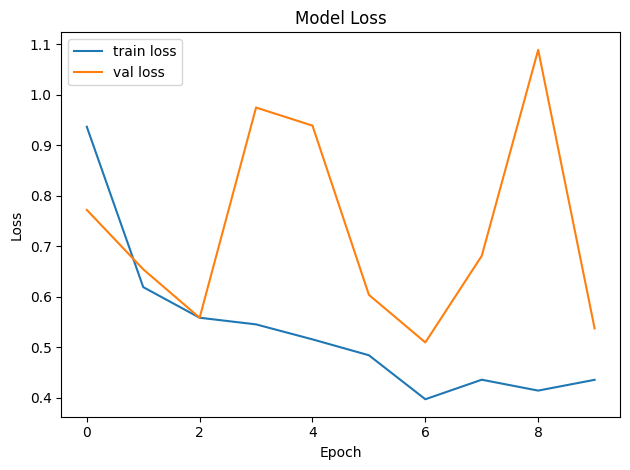

In [14]:
# Loss plot
fig, ax = plt.subplots()
ax.plot(history.history["loss"], label="train loss")
ax.plot(history.history["val_loss"], label="val loss")
ax.set_title("Model Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(export_dir, "loss.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

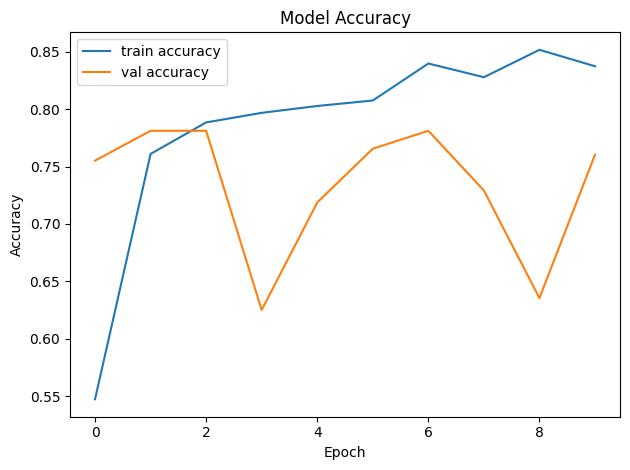

In [15]:
# Accuracy plot
fig, ax = plt.subplots()
ax.plot(history.history["accuracy"], label="train accuracy")
ax.plot(history.history["val_accuracy"], label="val accuracy")
ax.set_title("Model Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(export_dir, "accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

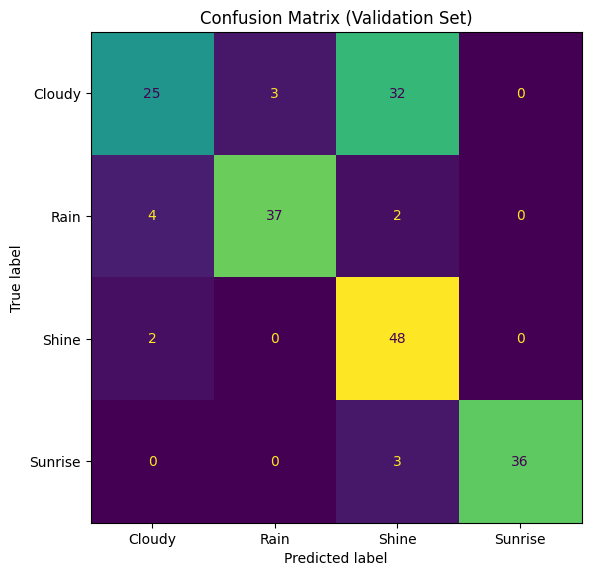

In [16]:
# Confusion Matrix

class_names = ["Cloudy", "Rain", "Shine", "Sunrise"]

# Predict on validation set
val_generator.reset()
val_steps = (val_generator.n // val_generator.batch_size) - 1

pred_probs = model.predict(val_generator, steps=val_steps, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes[:len(y_pred)]

cm = confusion_matrix(y_true, y_pred)

# Plot onto a specific figure/axes 
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format="d", colorbar=False)

ax.set_title("Confusion Matrix (Validation Set)")
fig.tight_layout()
fig.savefig(os.path.join(export_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

In [17]:
# Display random images and prediction

class_names = ["Cloudy", "Rain", "Shine", "Sunrise"]

def predict_one(model, generator, num_images=7):
    image_batch, classes_batch = next(generator)
    predicted_batch = model.predict(image_batch, verbose=0)

    for k in range(min(num_images, image_batch.shape[0])):
        image = image_batch[k]
        real_idx = np.argmax(classes_batch[k])
        pred_idx = np.argmax(predicted_batch[k])
        conf = np.max(predicted_batch[k])

        fig, ax = plt.subplots()
        ax.imshow(image)
        ax.set_title(
            f"{'Correct' if real_idx == pred_idx else 'Incorrect'} | "
            f"true: {class_names[real_idx]} | "
            f"pred: {class_names[pred_idx]} (p={conf:.2f})"
        )
        ax.axis("off")

        fname = f"{k:02d}_{class_names[real_idx]}_pred-{class_names[pred_idx]}_{conf:.2f}.png"
        fig.savefig(os.path.join(export_dir, fname), dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)

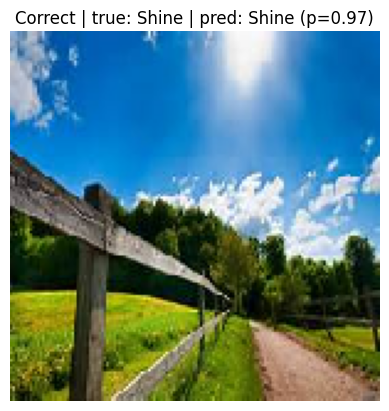

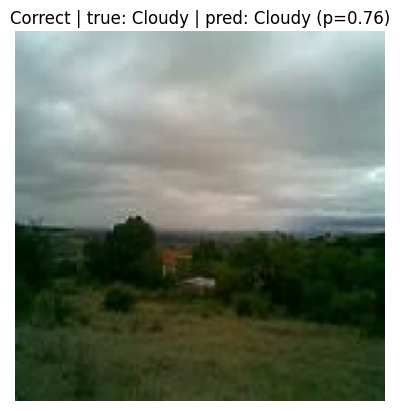

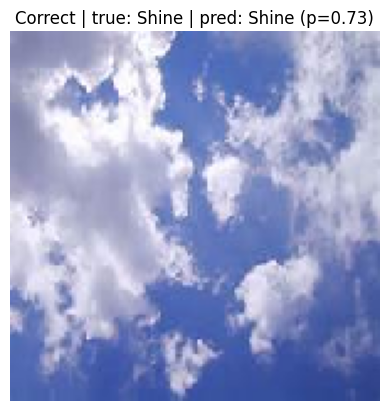

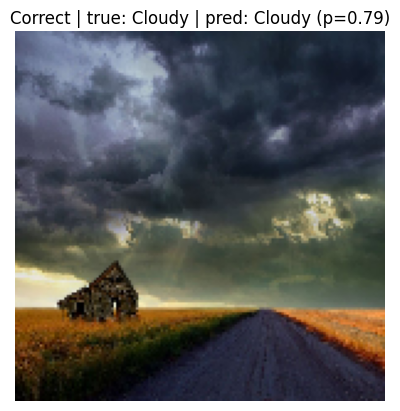

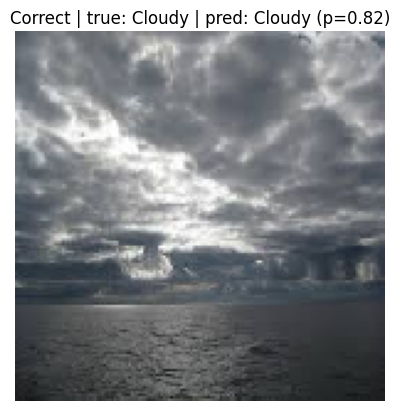

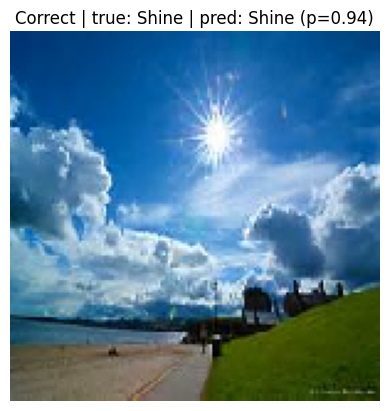

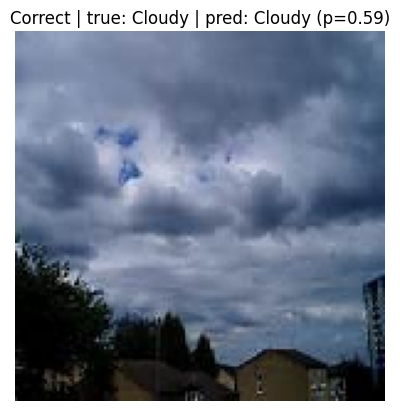

In [18]:
predict_one(model, train_generator, num_images=7)

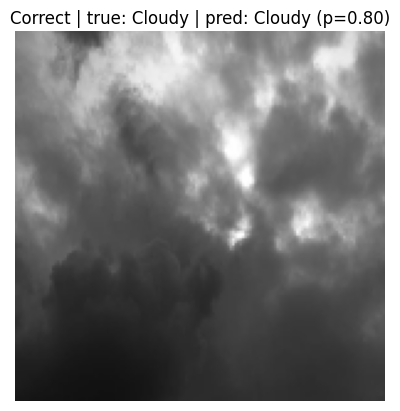

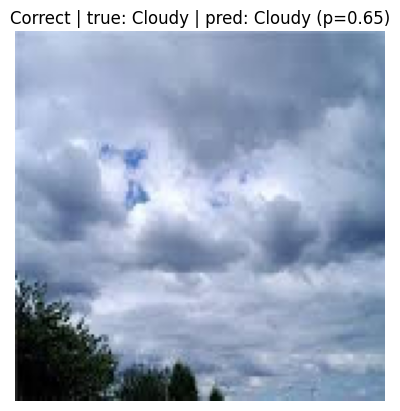

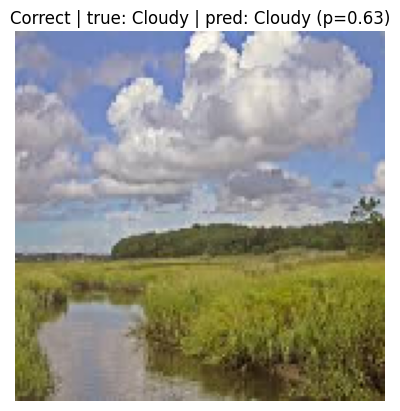

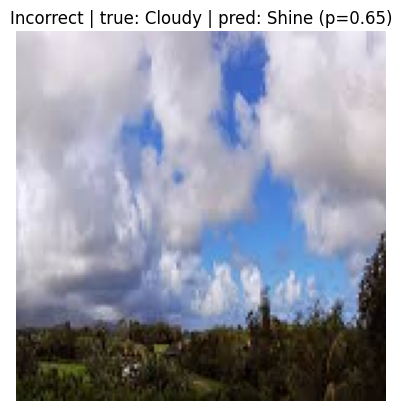

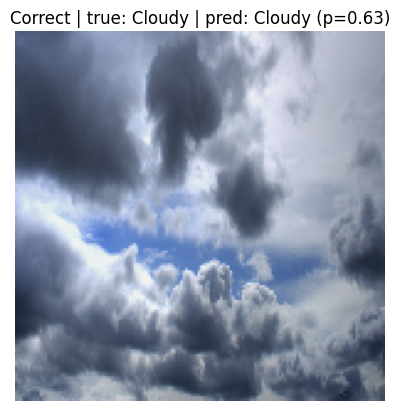

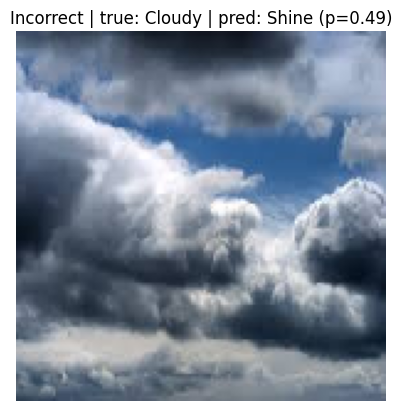

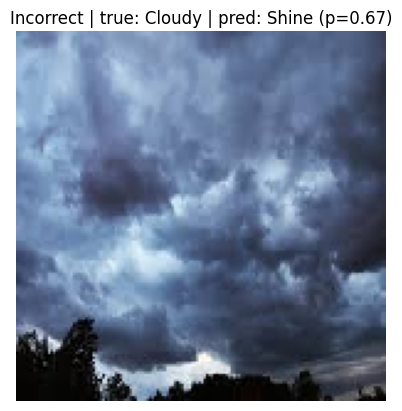

In [19]:
predict_one(model, val_generator, num_images=7)